## CONFIGURACIÓN DE GRAFICOS EJERCICIO 1

- Tiempo adecuado: mismo tamaño que la señal. Equiespaciado. Podemos usar las funciones 
    - np.linspace(Start, Stop, N)
    - np.arange(Start, Stop, Step)

Inicializamos una figura con plt.figure(figsize=(10, 5))

- Titulo: plt.title("Titulo")
- Colores: Dentro del plt.plot(color="colordeseado")

![Texto descriptivo](colorpython.png)


- Grosor de líneas: Dentro del plt.plot(linewidth=2.5)
- Estilo de líneas: Dentro de Dentro del plt.plot(linestyle="--")
![Texto descriptivo](linestyles.png)

- Etiquetas: plt.plot(label="Nombre")y luego plt.legend(loc="upper right")
- Anotaciones: Investigar.
- Superposición: Varios plt.plot() sin un plt.show() en el medio.

Se recomienda agregar un plt.tight_layout() al final para mejorar la disposicion de los gráficos.

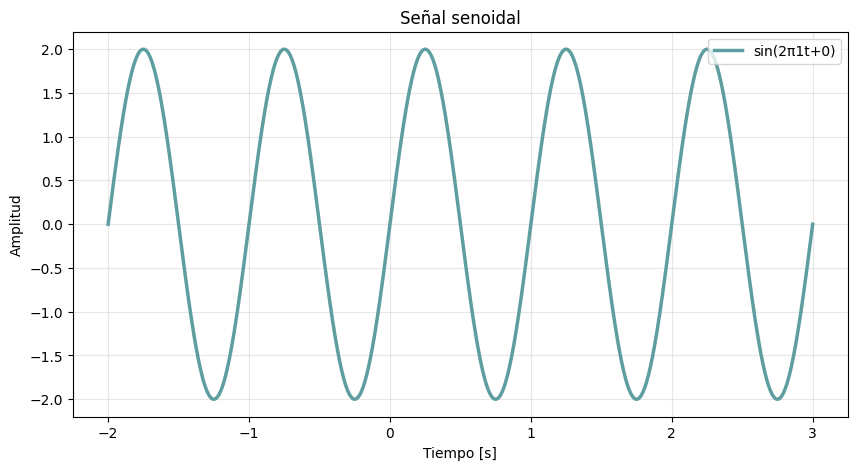

In [23]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt

# Definicion del eje temporal
t = np.linspace(-2, 3, 1000) #Inicio, fin, cantidad de muestras

# Senal senoidal
Amp = 2
freq = 1 # En Hz
fase = 0  # En radianes
seno = Amp * np.sin(2 * np.pi * freq * t + fase)

plt.figure(figsize=(10, 5))
plt.plot(
    t, seno,
    color="cadetblue",          # Color
    linewidth=2.5,         # Grosor de la línea
    label="sin(2π" + str(freq) +"t+"+ str(fase) + ")"      # Label
)

# Título y ejes
plt.title("Señal senoidal")     # Titulo
plt.xlabel("Tiempo [s]")        # Label eje x
plt.ylabel("Amplitud")          # Label eje y

plt.grid(True, alpha=0.3)       # Grilla (opcional)
plt.legend(loc="upper right")                    # Leyenda


## CARGA DE DATOS EJERCICIO 2

https://physionet.org/content/ephnogram/1.0.0

Usamos el primer archivo, ECGPCG0001.mat. El archivo es un .mat, un formato de archivo de matlab, por lo quie tendremos que usar una funcion especifica para ello, de la libreria scipy.

Lo abrimos y lo exploramos. Usamos la función squeeze. La función squeeze() en Python, principalmente utilizada en NumPy (numpy.squeeze), elimina las dimensiones de tamaño 1 de un array (entradas unidimensionales). Es ideal para simplificar la estructura de los datos, convirtiendo, por ejemplo, un array de forma (1, 3, 1) a (3,)

In [24]:
from scipy.io import loadmat


data = loadmat("E:\SyS\TPs\ECGPCG0001.mat")
#data = loadmat("/media/pedro/Expansion/SyS/TPs/ECGPCG0001.mat")
print(data.keys())
ecg = data["ECG"].squeeze()
pcg = data["PCG"].squeeze()
fs = data["fs"].squeeze()

print("Forma ECG:", ecg.shape)
print("Forma PCG:", pcg.shape)
print("Frecuencia de muestreo:", fs, "Hz")

dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'PCG', 'fs'])
Forma ECG: (14400000,)
Forma PCG: (14400000,)
Frecuencia de muestreo: 8000 Hz


## EJEMPLO EJERCICIO 3


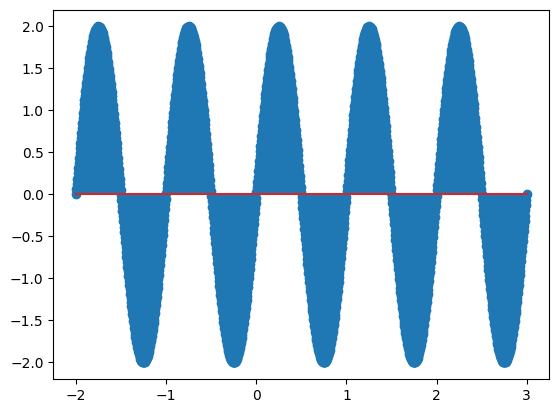

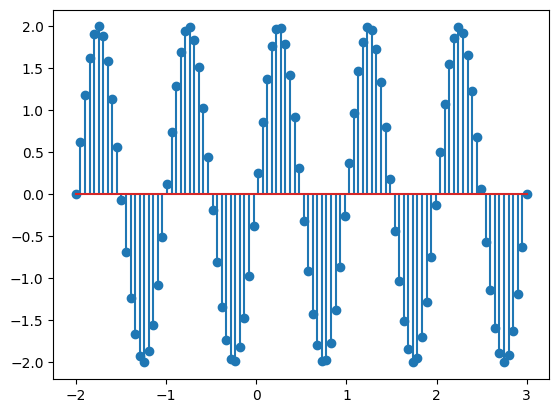

In [25]:
#Si los puntos estan tan separados se ve feo.
markerline, stemlines, baseline = plt.stem(t, seno,  bottom=0) # t = t = np.linspace(-2, 3, 1000) 
plt.show()

#Creamos un array temporal con menos muestras.
t_d = np.linspace(-2,3,100)
Amp_d = 2
freq_d = 1 # En Hz
fase_d = 0  # En radianes
seno_d = Amp * np.sin(2 * np.pi * freq * t_d + fase)

markerline, stemlines, baseline = plt.stem(t_d, seno_d,  bottom=0)
plt.show()

## EJEMPLO EJERCICIO 4
Vamos primero a generar 6 señales senoidales con 6 frecuencias distintas:
- 0.01 Hz
- 0.1 Hz
- 0.318 Hz
- 0.5 Hz
- 3 Hz
- 10 Hz

In [26]:
from scipy import signal as sg
import control as ct
import numpy as np
import matplotlib.pyplot as plt

Start: 0 Stop: 50 Step:  0.0001


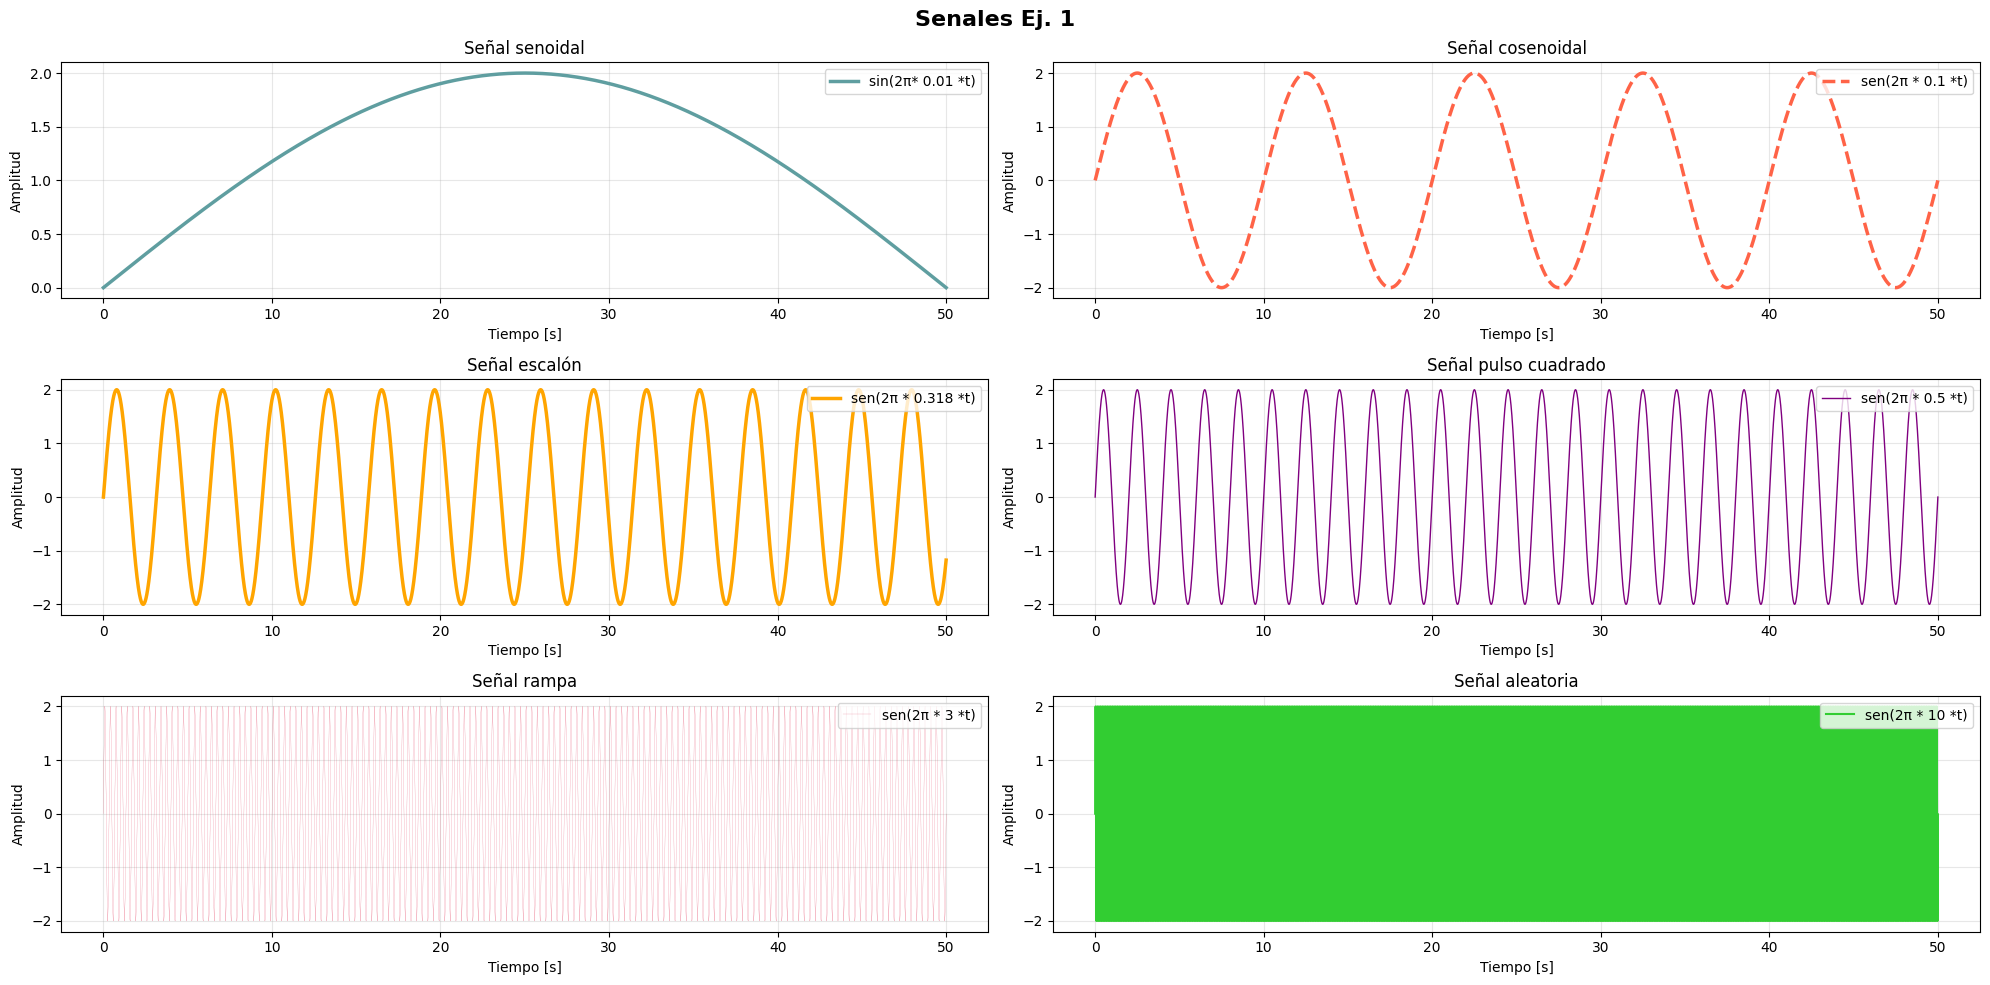

In [ ]:
f0 = 10e3
T0 = 1/f0

t = np.arange(0, 50, T0) # Array temporal: start=0, stop=0.0004, step=1.000e-03
print("Start:",0,"Stop:", 50,"Step: ", T0)
#k = np.arange(-10.,11,1) # Indices (kn): start=-10, stop=11, step=1
#wk = (2 * np.pi*f0)*k # Frecuencias angulares armonicas: 2 * pi * 10e3 * k:(-10,11)

entrada1 = 2 * np.sin(2 * np.pi * 0.01 * t + 0)
entrada2 = 2 * np.sin(2 * np.pi * 0.1 * t + 0)
entrada3 = 2 * np.sin(2 * np.pi * 0.318  * t + 0)
entrada4 = 2 * np.sin(2 * np.pi * 0.5 * t + 0)
entrada5 = 2 * np.sin(2 * np.pi * 3 * t + 0)
entrada6 = 2 * np.sin(2 * np.pi * 10 * t + 0)



fig, axs = plt.subplots(3, 2, figsize=(20, 10))
fig.suptitle("Senales Ej. 1", fontsize=16, fontweight="bold")

axs[0, 0].plot(
    t, entrada1,
    color="cadetblue",         
    linewidth=2.5,         
    label="sin(2π* 0.01 *t)"      
)
axs[0, 0].set_title("Señal senoidal")           
axs[0, 0].set_xlabel("Tiempo [s]")              
axs[0, 0].set_ylabel("Amplitud")                
axs[0, 0].grid(True, alpha=0.3)                 
axs[0, 0].legend(loc="upper right")                              

axs[0, 1].plot(
    t, entrada2,
    color="tomato",
    linewidth=2.5,
    linestyle="--",       
    label="sen(2π * 0.1 *t)"
)
axs[0, 1].set_title("Señal cosenoidal")
axs[0, 1].set_xlabel("Tiempo [s]")
axs[0, 1].set_ylabel("Amplitud")
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend(loc="upper right")


axs[1, 0].plot(
    t, entrada3,
    color="orange",
    linewidth=2.5,
    label="sen(2π * 0.318 *t)"
)
axs[1, 0].set_title("Señal escalón")
axs[1, 0].set_xlabel("Tiempo [s]")
axs[1, 0].set_ylabel("Amplitud")
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend(loc="upper right")

axs[1, 1].plot(
    t, entrada4,
    color="purple",
    linewidth=1,
    label="sen(2π * 0.5 *t)"
)
axs[1, 1].set_title("Señal pulso cuadrado")
axs[1, 1].set_xlabel("Tiempo [s]")
axs[1, 1].set_ylabel("Amplitud")
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend(loc="upper right")


axs[2, 0].plot(
    t, entrada5,
    color="crimson",
    linewidth=0.1,
    label="sen(2π * 3 *t)"
)
axs[2, 0].set_title("Señal rampa")
axs[2, 0].set_xlabel("Tiempo [s]")
axs[2, 0].set_ylabel("Amplitud")
axs[2, 0].grid(True, alpha=0.3)
axs[2, 0].legend(loc="upper right")


axs[2, 1].plot(
    t, entrada6,
    color="limegreen",
    linewidth=1.5,
    label="sen(2π * 10 *t)"
)
axs[2, 1].set_title("Señal aleatoria")
axs[2, 1].set_xlabel("Tiempo [s]")
axs[2, 1].set_ylabel("Amplitud")
axs[2, 1].grid(True, alpha=0.3)
axs[2, 1].legend(loc="upper right")
plt.tight_layout()

# =========================================================
# 6) MOSTRAR
# =========================================================
plt.show()


Ahora vamos a usar estas señales como entrada de un sistema.

Usamos el sistema visto en clase:
$ H_{(s)} = \frac{s}{s+2}$

¿Qué tipo de filtro era?

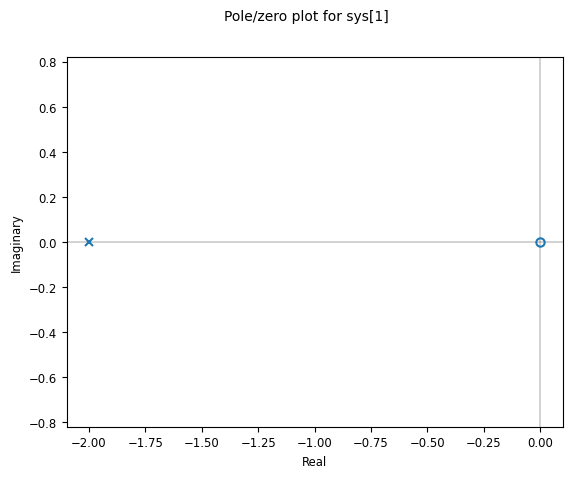

In [28]:
num = [1, 0]
den = [1, 2]
sys_tf = sg.TransferFunction(num, den)

ct.pzmap(ct.tf(num,den))

#Simulacion del sistema en función de transferencia 
Ci = np.array([0]) #Condiciones inciales nulas.
_,yout1_out,_= sg.lsim(sys_tf,entrada1,t,Ci) #Respuesta temporal del sistema.
_,yout2_out,_= sg.lsim(sys_tf,entrada2,t,Ci) #Respuesta temporal del sistema.
_,yout3_out,_= sg.lsim(sys_tf,entrada3,t,Ci) #Respuesta temporal del sistema.
_,yout4_out,_= sg.lsim(sys_tf,entrada4,t,Ci) #Respuesta temporal del sistema.
_,yout5_out,_= sg.lsim(sys_tf,entrada5,t,Ci) #Respuesta temporal del sistema.
_,yout6_out,_= sg.lsim(sys_tf,entrada6,t,Ci) #Respuesta temporal del sistema.

Text(0.5, 0, '$ \\omega $')

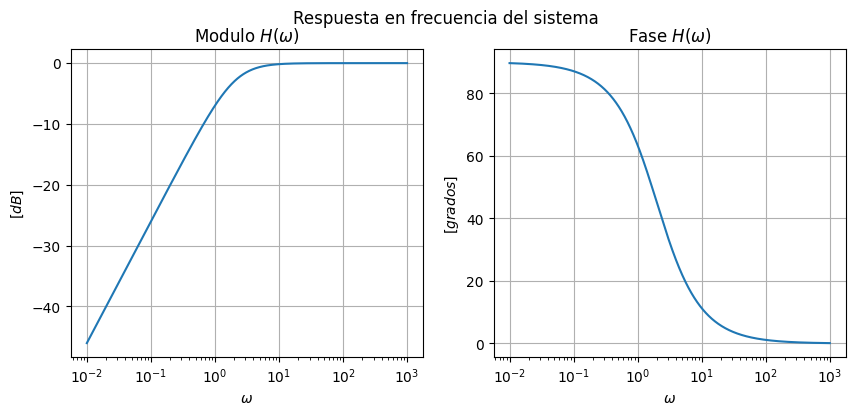

In [ ]:
w = np.logspace(-2,3,1000) #Eje de las frecuencias angulares (w).
_,H = sg.freqresp(sys_tf,w) #Evaluamos la respuesta en frecuencia en cada frecuencia angular.
modH = 20*np.log10(np.abs(H)) #Modulo en decibeles
fi = np.angle(H) #Fase

fig, (ax1, ax2)=plt.subplots(1,2,figsize=(10, 4))

fig.suptitle(r"Respuesta en frecuencia del sistema")

ax1.semilogx(w,modH)
ax1.grid(True)
ax1.set_title(r"Modulo $H(\omega)$") 
ax1.set_ylabel(r"$[dB]$") 
ax1.set_xlabel(r'$\omega $')

ax2.semilogx(w,fi*180/np.pi)
ax2.grid(True)
ax2.set_title(r"Fase $H(\omega)$")
ax2.set_ylabel(r"$[grados]$") 
ax2.set_xlabel(r'$ \omega $')

¿Qué tipo de filtro es?

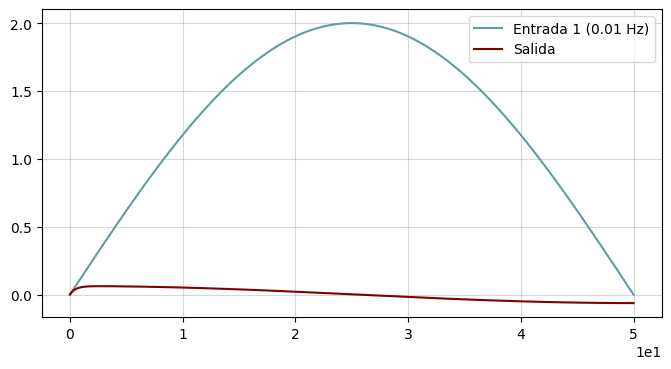

In [ ]:
#Grafico de la simulacion del sistema
plt.figure(figsize=(8, 4));

plt.plot(t,entrada1,
    color="cadetblue",
label="Entrada 1 (0.01 Hz)")
plt.plot(t,yout1_out,
         color = "maroon",
label="Salida")
plt.grid(True,alpha=0.5)

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc="upper right")                   
plt.show()

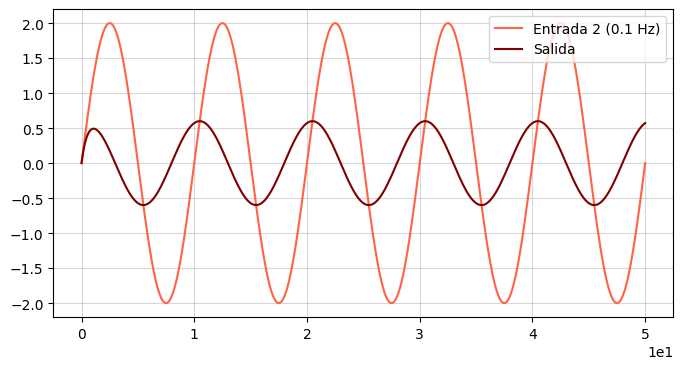

In [ ]:
#Grafico de la simulacion del sistema
plt.figure(figsize=(8, 4));

plt.plot(t,entrada2,
         color="tomato",
label="Entrada 2 (0.1 Hz)")
plt.plot(t,yout2_out,
         color = "maroon",
label="Salida")
plt.grid(True,alpha=0.5)

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc="upper right")                   
plt.show()

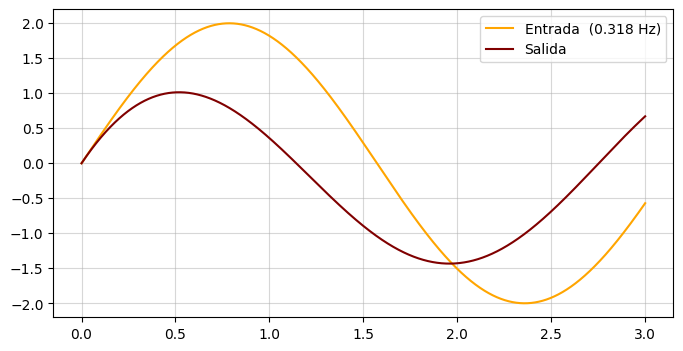

In [ ]:
#Grafico de la simulacion del sistema
plt.figure(figsize=(8, 4));

plt.plot(t[0:30000],entrada3[0:30000],
         color="orange",
label="Entrada  (0.318 Hz)")
plt.plot(t[0:30000],yout3_out[0:30000],
         color = "maroon",
label="Salida")
plt.grid(True,alpha=0.5)

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc="upper right")                   
plt.show()

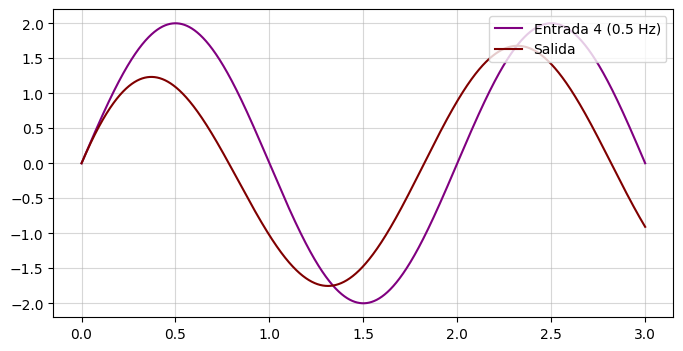

In [ ]:
#Grafico de la simulacion del sistema
plt.figure(figsize=(8, 4));

plt.plot(t[0:30000],entrada4[0:30000],
         color="purple",
label="Entrada 4 (0.5 Hz)")
plt.plot(t[0:30000],yout4_out[0:30000],
         color = "maroon",
label="Salida")
plt.grid(True,alpha=0.5)

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc="upper right")                   
plt.show()

500000


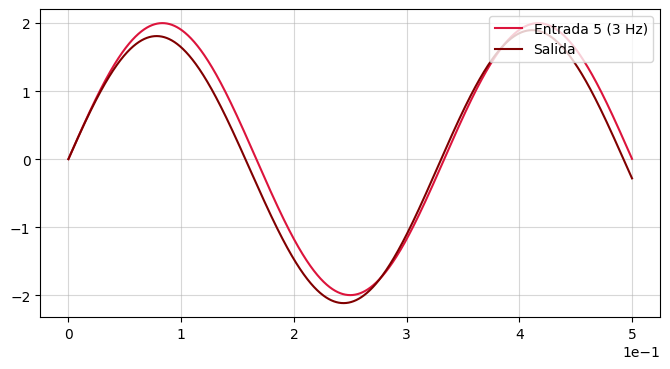

In [ ]:
#Grafico de la simulacion del sistema
plt.figure(figsize=(8, 4));

plt.plot(t[0:5000],entrada5[0:5000],
         color="crimson",
label="Entrada 5 (3 Hz)")

plt.plot(t[0:5000],yout5_out[0:5000],
         color = "maroon",
label="Salida")
plt.grid(True,alpha=0.5)

print(len(t))
ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc="upper right")                   
plt.show()

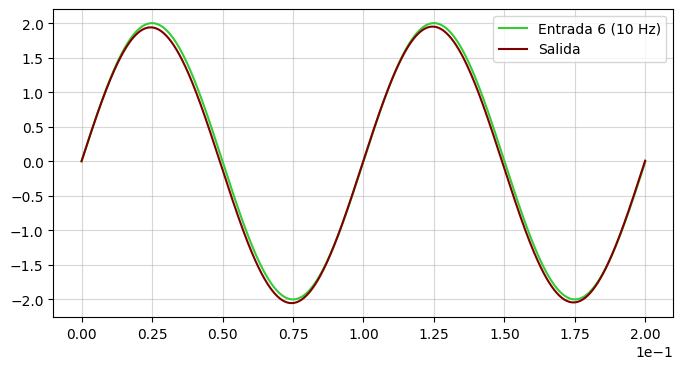

In [ ]:
#Grafico de la simulacion del sistema
plt.figure(figsize=(8, 4));

plt.plot(t[0:2000],entrada6[0:2000],
         color="limegreen",
label="Entrada 6 (10 Hz)")
plt.plot(t[0:2000],yout6_out[0:2000],
         color = "maroon",
label="Salida")
plt.grid(True,alpha=0.5)

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc="upper right")                   
plt.show()